# EDA

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Configuracoes de visualizacao
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
pd.options.display.float_format = '{:,.2f}'.format

In [2]:
df = pd.read_parquet('../data/instacart_orders.parquet')

print(df.shape)
df.head()

(32434489, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.00,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.00,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.00,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.00,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.00,Natural Sweetener,17,13,baking ingredients,pantry


## Sanity check

In [3]:
# Validando tipos de colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 15 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   product_id              int32   
 2   add_to_cart_order       int64   
 3   reordered               int64   
 4   user_id                 int32   
 5   eval_set                object  
 6   order_number            int64   
 7   order_dow               int64   
 8   order_hour_of_day       int64   
 9   days_since_prior_order  float64 
 10  product_name            object  
 11  aisle_id                int64   
 12  department_id           int64   
 13  aisle                   category
 14  department              category
dtypes: category(2), float64(1), int32(3), int64(7), object(2)
memory usage: 2.9+ GB


In [4]:
# Validando valores nulos
df.isna().sum()

order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64

In [5]:
# Faz sentido na coluna days_since_prior_order termos valores nulos, uma vez que o primeiro pedido de um usuário, não tem pedido anterior para comparar
(
    df['days_since_prior_order'].isna()
    ==
    (df['order_number'] == 1)
).mean()

np.float64(1.0)

In [6]:
df.nunique()

order_id                  3214874
product_id                  49677
add_to_cart_order             145
reordered                       2
user_id                    206209
eval_set                        1
order_number                   99
order_dow                       7
order_hour_of_day              24
days_since_prior_order         31
product_name                49677
aisle_id                      134
department_id                  21
aisle                         134
department                     21
dtype: int64

In [7]:
# Validação de linhas duplicadas
df.duplicated().sum()

np.int64(0)

In [8]:
# Validação se um mesmo produto aparece duas vezes no mesmo pedido
df.duplicated(
    subset=['order_id','product_id']
).sum()

np.int64(0)

In [9]:
print("=== Variaveis Numericas ===")
display(df.describe())

print("=== Variaveis Categoricas ===")
display(df.describe(include="object"))

=== Variaveis Numericas ===


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
count,"32,434,489.00","32,434,489.00","32,434,489.00","32,434,489.00","32,434,489.00","32,434,489.00","32,434,489.00","32,434,489.00","30,356,421.00","32,434,489.00","32,434,489.00"
mean,"1,710,748.52","25,576.34",8.35,0.59,"102,937.24",17.14,2.74,13.42,11.10,71.21,9.92
std,"987,300.70","14,096.69",7.13,0.49,"59,466.48",17.54,2.09,4.25,8.78,38.20,6.28
min,2.00,1.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,1.00
25%,"855,943.00","13,530.00",3.00,0.00,"51,421.00",5.00,1.00,10.00,5.00,31.00,4.00
50%,"1,711,048.00","25,256.00",6.00,1.00,"102,611.00",11.00,3.00,13.00,8.00,83.00,9.00
75%,"2,565,514.00","37,935.00",11.00,1.00,"154,391.00",24.00,5.00,16.00,15.00,107.00,16.00
max,"3,421,083.00","49,688.00",145.00,1.00,"206,209.00",99.00,6.00,23.00,30.00,134.00,21.00


=== Variaveis Categoricas ===


,eval_set,product_name
count,32434489,32434489
unique,1,49677
top,prior,Banana
freq,32434489,472565


In [10]:
# Vendo quantos usuários, produtos e pedidos existem
print(df['user_id'].nunique())
print(df['product_id'].nunique())
print(df['order_id'].nunique())

206209
49677
3214874


In [11]:
top_products = (
    df['product_name']
      .value_counts()
      .head(20)
)

top_products

product_name
Banana                      472565
Bag of Organic Bananas      379450
Organic Strawberries        264683
Organic Baby Spinach        241921
Organic Hass Avocado        213584
Organic Avocado             176815
Large Lemon                 152657
Strawberries                142951
Limes                       140627
Organic Whole Milk          137905
Organic Raspberries         137057
Organic Yellow Onion        113426
Organic Garlic              109778
Organic Zucchini            104823
Organic Blueberries         100060
Cucumber Kirby               97315
Organic Fuji Apple           89632
Organic Lemon                87746
Apple Honeycrisp Organic     85020
Organic Grape Tomatoes       84255
Name: count, dtype: int64

In [12]:
# Maiores departamentos
df['department'].value_counts()

department
produce            9479291
dairy eggs         5414016
snacks             2887550
beverages          2690129
frozen             2236432
pantry             1875577
bakery             1176787
canned goods       1068058
deli               1051249
dry goods pasta     866627
household           738666
breakfast           709569
meat seafood        708931
personal care       447123
babies              423802
international       269253
alcohol             153696
pets                 97724
missing              69145
other                36291
bulk                 34573
Name: count, dtype: int64

<Axes: >

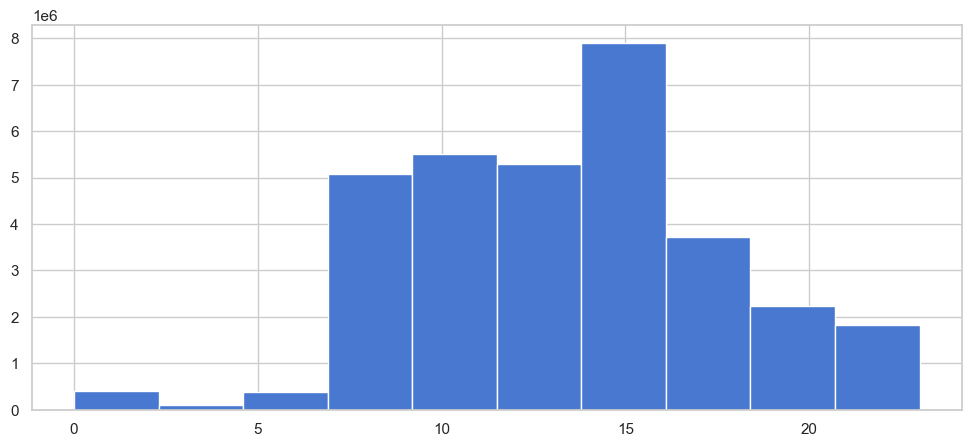

In [13]:
# Horários de compras
df['order_hour_of_day'].hist()

In [14]:
# Taxa de recompra
print(f'{df['reordered'].mean() * 100:.2f}%')

58.97%


In [15]:
# Quantidade de compras por usuário
orders_per_user = (
    df.groupby('user_id')['order_id']
      .nunique()
)
orders_per_user

user_id
1         10
2         14
3         12
4          5
5          4
          ..
206205     3
206206    67
206207    16
206208    49
206209    13
Name: order_id, Length: 206209, dtype: int64

In [16]:
interactions = (
    df[
        ["user_id", "product_id"]
    ]
    .drop_duplicates()
    .copy()
)

interactions["interaction"] = 1

interactions.head()

,user_id,product_id,interaction
0,202279,33120,1
1,202279,28985,1
2,202279,9327,1
3,202279,45918,1
4,202279,30035,1


In [17]:
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

interactions["user_idx"] = user_encoder.fit_transform(
    interactions["user_id"]
)

interactions["item_idx"] = item_encoder.fit_transform(
    interactions["product_id"]
)

In [18]:
import numpy as np

all_products = interactions["item_idx"].unique()

negative_samples = []

for user in interactions["user_idx"].unique():

    bought = set(
        interactions.loc[
            interactions["user_idx"] == user,
            "item_idx"
        ]
    )

    n_negatives = len(bought)

    candidates = np.setdiff1d(
        all_products,
        list(bought)
    )

    sampled = np.random.choice(
        candidates,
        size=min(n_negatives, len(candidates)),
        replace=False
    )

    for item in sampled:
        negative_samples.append(
            [user, item, 0]
        )

negative_df = pd.DataFrame(
    negative_samples,
    columns=[
        "user_idx",
        "item_idx",
        "interaction"
    ]
)

KeyboardInterrupt: 

In [ ]:
positive_df = interactions[
    ["user_idx", "item_idx", "interaction"]
]

dataset = pd.concat(
    [positive_df, negative_df],
    ignore_index=True
)

dataset = dataset.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    stratify=dataset["interaction"]
)

In [ ]:
import torch
from torch.utils.data import Dataset

In [ ]:
class InteractionDataset(Dataset):

    def __init__(self, df):

        self.users = torch.tensor(
            df["user_idx"].values,
            dtype=torch.long
        )

        self.items = torch.tensor(
            df["item_idx"].values,
            dtype=torch.long
        )

        self.labels = torch.tensor(
            df["interaction"].values,
            dtype=torch.float32
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        return (
            self.users[idx],
            self.items[idx],
            self.labels[idx]
        )

In [ ]:
from torch.utils.data import DataLoader

train_dataset = InteractionDataset(
    train_df
)

test_dataset = InteractionDataset(
    test_df
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1024,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1024
)

In [ ]:
import torch.nn as nn
class RecommenderNet(nn.Module):

    def __init__(
        self,
        n_users,
        n_items,
        embedding_dim=64
    ):

        super().__init__()

        self.user_embedding = nn.Embedding(
            n_users,
            embedding_dim
        )

        self.item_embedding = nn.Embedding(
            n_items,
            embedding_dim
        )

        self.fc = nn.Sequential(
            nn.Linear(
                embedding_dim * 2,
                128
            ),
            nn.ReLU(),

            nn.Linear(
                128,
                64
            ),
            nn.ReLU(),

            nn.Linear(
                64,
                1
            )
        )

    def forward(
        self,
        users,
        items
    ):

        user_vec = self.user_embedding(users)

        item_vec = self.item_embedding(items)

        x = torch.cat(
            [user_vec, item_vec],
            dim=1
        )

        return self.fc(x).squeeze()

In [ ]:
n_users = dataset["user_idx"].nunique()

n_items = dataset["item_idx"].nunique()

model = RecommenderNet(
    n_users=n_users,
    n_items=n_items
)

In [ ]:
criterion = nn.BCEWithLogitsLoss()

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 5

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for users, items, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(
            users,
            items
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} "
        f"Loss={total_loss:.4f}"
    )

In [ ]:
sample_users = (
    df["user_id"]
    .drop_duplicates()
    .sample(
        50000,
        random_state=42
    )
)

prior_sample = df[
    df["user_id"]
    .isin(sample_users)
]